# Práctica 1 — Modelo de pérdidas del ramo de Incendios
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Facultad de Ciencias, UNAM

**Equipo 08 · Ramo: Incendios**

---
Con la cartera de nuestro ramo, modelamos la **severidad** y la
**frecuencia**, simulamos la **pérdida agregada S** y sacamos de ahí la **prima pura preliminar**
del producto.

---
## 0. Entorno

In [9]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm

np.random.seed(8)   
plt.rcParams["figure.figsize"] = (9, 4)
print("✓ Entorno listo")

✓ Entorno listo


---
## 1. Cargar datos y explorar las variables de interés

Para esta práctica **solo nos importan algunas columnas**
(la agregada, sin factores de riesgo):

| Necesito para... | Variable | Qué es |
|---|---|---|
| Frecuencia | `num_siniestros`, `exposicion` | número de siniestros de la póliza y años-póliza expuestos |
| Severidad | `monto_promedio_siniestro` | monto ground-up (daño real) promedio por siniestro de la póliza |
| Transformar la póliza | `deducible`, `coaseguro`, `suma_asegurada` | condiciones del contrato, para pasar de severidad real a la que paga la aseguradora |

El resto de columnas (`tipo_inmueble`, `material_construccion`, `uso_inmueble`, `giro`,
`medidas_proteccion`, `antiguedad_inmueble`, `zona`) **existen pero no se usan en esta práctica**:
son los factores de riesgo por póliza que sí vamos a explotar en la Práctica 2 con un GLM.

In [10]:
df = pd.read_parquet("../inputs/cartera.parquet")
print(f"Pólizas: {len(df):,} | Columnas: {len(df.columns)}")
print("\nVariables que usamos en la Práctica 1:")
print("  frecuencia : num_siniestros, exposicion")
print("  severidad  : monto_promedio_siniestro (ground-up)")
print("  póliza     : deducible, suma_asegurada, coaseguro (para transformar)")
print("\nNo se usan aquí (factores de riesgo, para el GLM de la Práctica 2):")
print(" ", [c for c in df.columns if c not in
      ["id_poliza","exposicion","num_siniestros","monto_promedio_siniestro",
       "monto_total_siniestros","deducible","coaseguro","suma_asegurada"]])

Pólizas: 30,000 | Columnas: 15

Variables que usamos en la Práctica 1:
  frecuencia : num_siniestros, exposicion
  severidad  : monto_promedio_siniestro (ground-up)
  póliza     : deducible, suma_asegurada, coaseguro (para transformar)

No se usan aquí (factores de riesgo, para el GLM de la Práctica 2):
  ['tipo_inmueble', 'material_construccion', 'uso_inmueble', 'giro', 'medidas_proteccion', 'antiguedad_inmueble', 'zona']


% de pólizas con siniestro : 2.81%
Distribución de num_siniestros:
num_siniestros
0    29156
1      814
2       30

Exposición total           : 24,006.2 años-póliza
Exposición por póliza      : media 0.800, rango [0.233, 0.999]

Severidad (monto_promedio_siniestro), solo pólizas con siniestro:
count         844.0
mean      1101539.0
std       3707539.0
min          2022.0
25%         83806.0
50%        260545.0
75%        742485.0
max      65619863.0


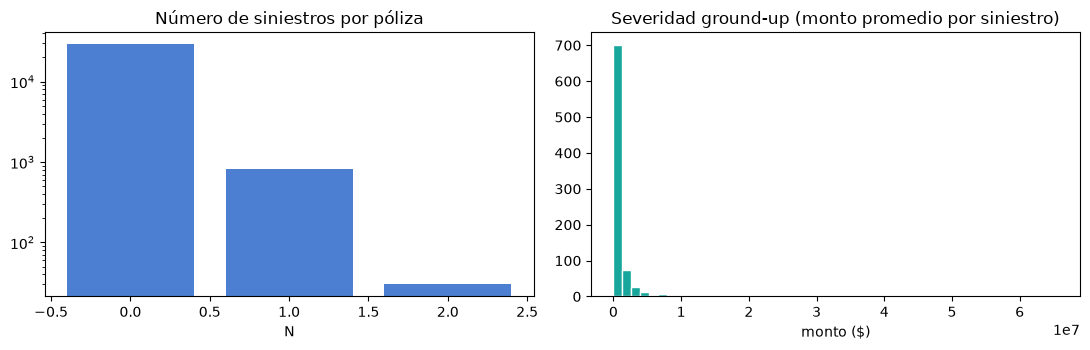

In [11]:
# ─── Exploración enfocada: solo número de siniestros, exposición y monto ───
con = df[df.num_siniestros > 0]                       # pólizas con al menos un siniestro

print(f"% de pólizas con siniestro : {(df.num_siniestros > 0).mean():.2%}")
print(f"Distribución de num_siniestros:\n{df.num_siniestros.value_counts().sort_index().to_string()}")
print(f"\nExposición total           : {df.exposicion.sum():,.1f} años-póliza")
print(f"Exposición por póliza      : media {df.exposicion.mean():.3f}, rango [{df.exposicion.min():.3f}, {df.exposicion.max():.3f}]")
print(f"\nSeveridad (monto_promedio_siniestro), solo pólizas con siniestro:")
print(con.monto_promedio_siniestro.describe().round(0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
vals, cts = np.unique(df.num_siniestros, return_counts=True)
ax[0].bar(vals, cts, color="#4C7FD1")
ax[0].set_title("Número de siniestros por póliza"); ax[0].set_xlabel("N"); ax[0].set_yscale("log")
ax[1].hist(con.monto_promedio_siniestro, bins=50, color="#17A69B", edgecolor="white")
ax[1].set_title("Severidad ground-up (monto promedio por siniestro)"); ax[1].set_xlabel("monto ($)")
plt.tight_layout(); plt.show()

La cartera de Incendios es una cartera de **baja frecuencia** (solo ~2.8% de las
pólizas reportan algún siniestro en el periodo, casi todas con un único siniestro) y **severidad
muy sesgada**: la mediana está muy por debajo de la media, señal de una cola pesada — típico del
ramo, donde la mayoría de los siniestros son daños menores pero unos pocos son pérdidas totales del
inmueble.